In [2]:
%matplotlib inline

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("ggplot")
plt.rcParams["font.family"] = "Meiryo"

In [3]:
df = pd.DataFrame({
    "month": [
        "1月", "2月", "3月", "4月", "5月", "6月",
        "1月", "2月", "3月", "4月", "5月", "6月",
        "1月", "2月", "3月", "4月", "5月", "6月",
        "1月", "2月", "3月", "4月", "5月", "6月",
    ],
    "site": [
        "MELMB", "MELMB", "MELMB", "MELMB", "MELMB", "MELMB",
        "WSE", "WSE", "WSE", "WSE", "WSE", "WSE",
        "GSE", "GSE", "GSE", "GSE", "GSE", "GSE",
        "ISE", "ISE", "ISE", "ISE", "ISE", "ISE",
    ],
    "production": [
        12000, 13500, 12800, 14000, 15000, 14800,
        9000, 9500, 9800, 10200, 11000, 10800,
        18000, 18500, 19000, 20000, 21000, 22000,
        7000, 7600, 8000, 8500, 9000, 9500,
    ],
    "defects": [
        24, 32, 18, 40, 22, 15,
        30, 28, 45, 20, 18, 16,
        25, 30, 28, 35, 90, 105,
        10, 14, 12, 18, 20, 60,
    ],
})

In [4]:
df["ppm"] = (df["defects"] / df["production"] * 1000000).round(1)

In [6]:
def judge_monster(ppm):
    if ppm >= 5000:
        return "ドラゴン級"
    elif ppm >= 3000:
        return "オーク級"
    else:
        return "スライム級"

In [7]:
df["monster"] = df["ppm"].apply(judge_monster)

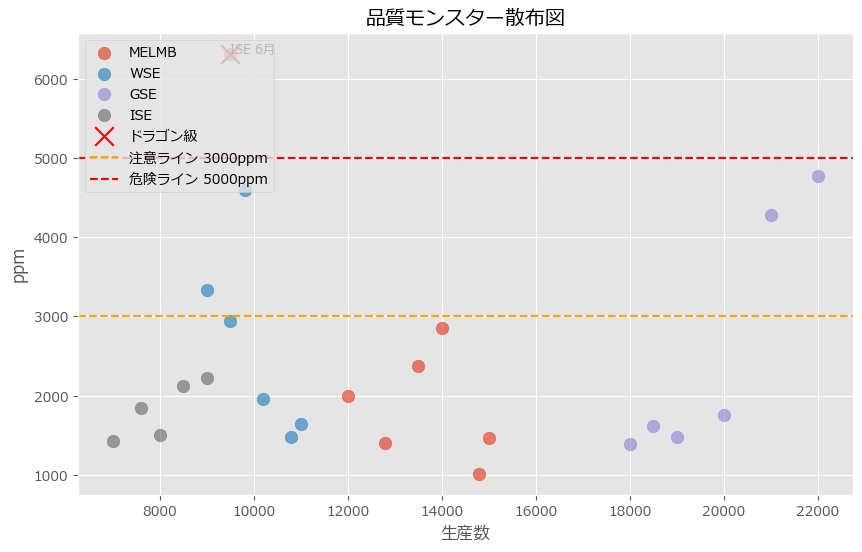

In [15]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)

sites = df["site"].unique()

for site in sites:
    site_df = df[df["site"] == site]
    ax.scatter(
        site_df["production"],
        site_df["ppm"],
        s=80,
        alpha=0.7,
        label=site,
    )

danger_df = df[df["monster"] == "ドラゴン級"]

ax.scatter(
    danger_df["production"],
    danger_df["ppm"],
    s=180,
    marker="x",
    color="red",
    label="ドラゴン級",
)

for _, row in danger_df.iterrows():
    ax.text(
        row["production"],
        row["ppm"],
        f"{row['site']} {row['month']}",
        fontsize=9,
    )

    ax.axhline(3000, linestyle="--", color="orange", label="注意ライン 3000ppm")
    ax.axhline(5000, linestyle="--", color="red", label="危険ライン 5000ppm")

    ax.set_title("品質モンスター散布図")
    ax.set_xlabel("生産数")
    ax.set_ylabel("ppm")
    ax.legend(loc="upper left")

    df